# Reverse Order Of Importance: Figures 8 And 9

This notebook reproduces Appendix Figures 8 and 9. The W&B tag is `ICLR-reversed`, where the most important interval is furthest away.


In [1]:
from analysis.utils import fetch_run_data, plot_combined_heads, plot_kl_divergence_simple, plot_val_loss_simple, report_head_color_map
import pandas as pd


SAVE_FIGURES = False


def output_path(name):
    return f"analysis/figures/{name}" if SAVE_FIGURES else None


In [2]:
RUN_ID = "seo4z7uz"
ATTENTION_STEPS = [0, 70, 375, 1500]
DIVERGENCE_STEPS = [2090, 2410]
MAX_STEPS = 3000

run_data = fetch_run_data(RUN_ID, metrics=["val_loss"])
cfg = run_data["config"]
pd.DataFrame(
    [{
        "run_id": RUN_ID,
        "name": run_data["name"],
        "tag": "ICLR-reversed",
        "reverse_constants": cfg["teacher"]["reverse_constants"],
        "span_lengths": cfg["teacher"]["span_lengths"],
        "architecture": "full transformer",
    }]
)


,run_id,name,tag,reverse_constants,span_lengths,architecture
0,seo4z7uz,sage-dust-1491,ICLR-reversed,True,"[2, 4, 8]",full transformer


## Figure 8: Reversed-Order Attention

The attention snapshots show that the model still learns incrementally even when the most important interval is farthest back in the context.


wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  


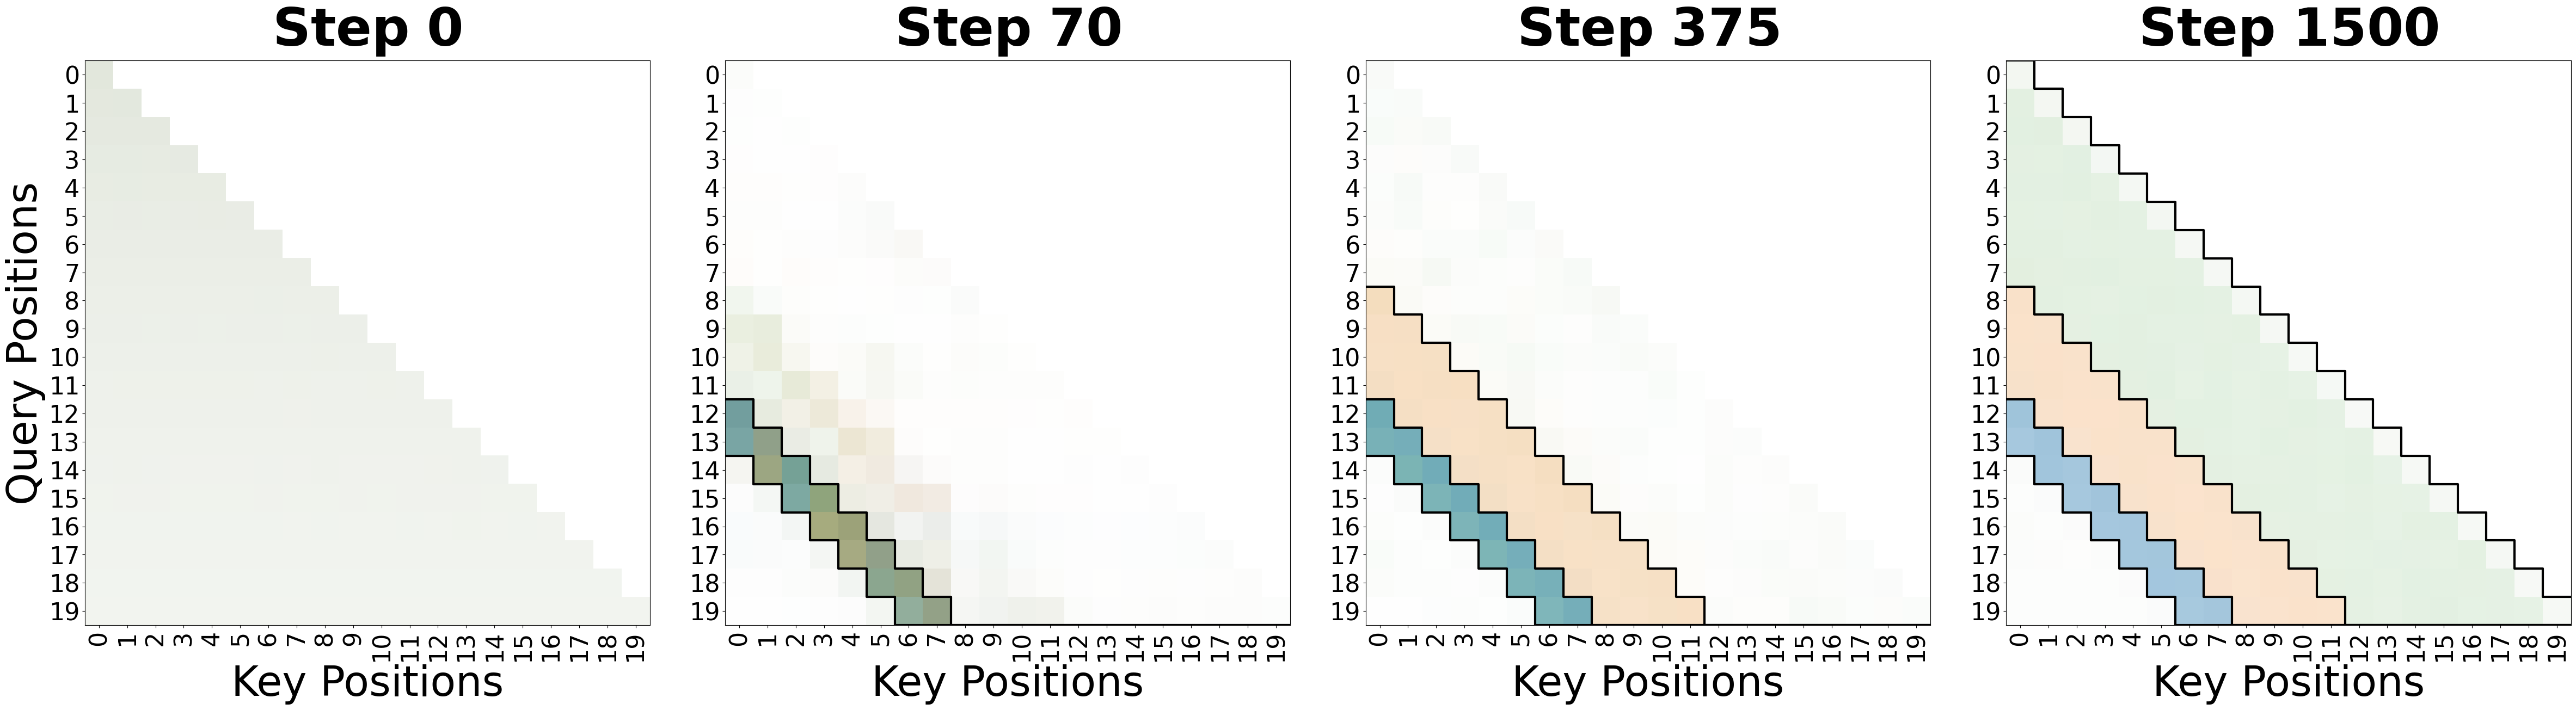

In [3]:
plot_combined_heads(
    RUN_ID,
    steps=ATTENTION_STEPS,
    split="val",
    head_colors=report_head_color_map([2, 1, 0]),
    staircases={1: [-12, -14], 2: [-12, -14, -8], 3: [-12, -14, -8, 0]},
    save_name=output_path("attention-reversed"),
)


## Figure 9: Reversed-Order Loss And KL

The shaded regions mark the same three stages after shifting the x-axis by the pretraining offset used in the report plots.


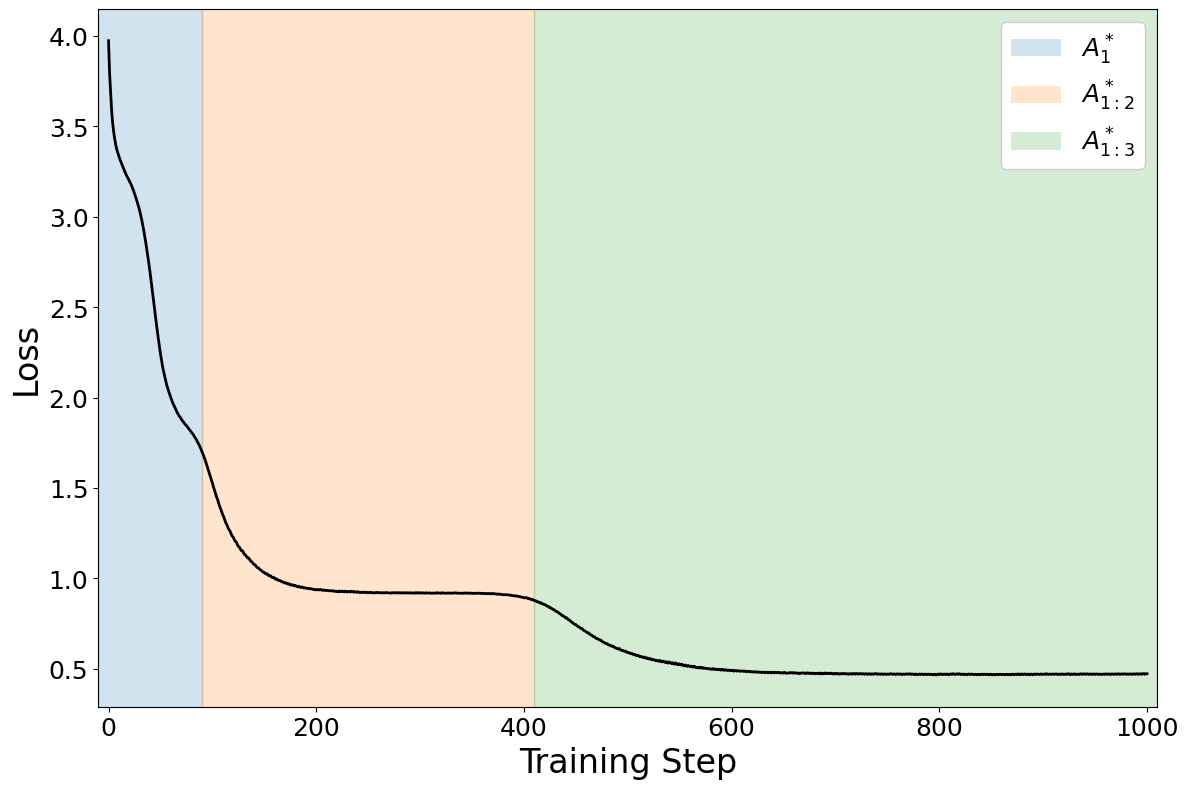

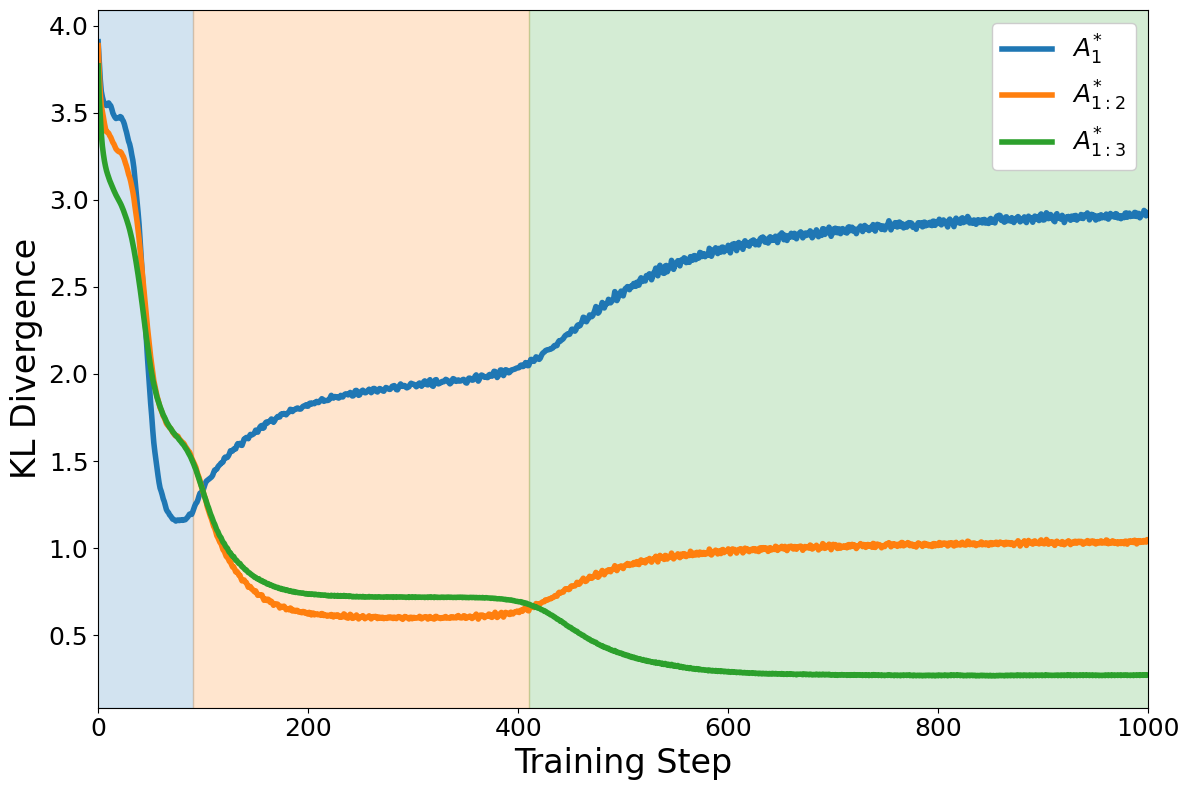

In [4]:
plot_val_loss_simple(
    run_id=RUN_ID,
    divergence_steps=DIVERGENCE_STEPS,
    max_steps=MAX_STEPS,
    figsize=(12, 8),
    shift_steps=True,
    save_name=output_path("val-loss-reversed"),
)

plot_kl_divergence_simple(
    run_id=RUN_ID,
    divergence_steps=DIVERGENCE_STEPS,
    max_steps=MAX_STEPS,
    figsize=(12, 8),
    learnable=False,
    shift_steps=True,
    save_name=output_path("kl-reversed"),
)
